In [16]:
import os
from pathlib import Path

print("="*60)
print("НАСТРОЙКА ПУТЕЙ")
print("="*60)

current = Path.cwd()
print(f"Текущая директория: {current}")

if current.name == "Notebooks":
    os.chdir(current.parent)
    print(f"Перешли в корень: {Path.cwd()}")
elif (current / "data").exists():
    print(f"Уже в корне: {current}")
else:
    desktop = Path("C:/Users/Владимир/Desktop")
    project_path = desktop / "Laboratory_2_sem-main"
    if project_path.exists():
        os.chdir(project_path)
        print(f"Перешли в проект: {Path.cwd()}")
    else:
        print(f"❌ Папка проекта не найдена!")

print("="*60)

НАСТРОЙКА ПУТЕЙ
Текущая директория: c:\Users\Владимир\Desktop\Laboratory_2_sem-main
Уже в корне: c:\Users\Владимир\Desktop\Laboratory_2_sem-main


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("="*60)
print("НЕДЕЛЯ 7: ВИЗУАЛИЗАЦИЯ ДАННЫХ")
print("="*60)
print(f"pandas версия: {pd.__version__}")

НЕДЕЛЯ 7: ВИЗУАЛИЗАЦИЯ ДАННЫХ
pandas версия: 2.3.3


# Проверяем, что даты правильно отсортированы
print("Проверка сортировки дат:")
print(f"Минимальная дата: {df['date'].min()}")
print(f"Максимальная дата: {df['date'].max()}")
print(f"Даты отсортированы: {df['date'].is_monotonic_increasing}")

# Проверяем пропуски
print(f"\nПропуски в value: {df['value'].isna().sum()} (только 2025 год)")

# Убираем пропуски для графиков (кроме временного ряда)
df_clean = df.dropna(subset=['value'])
print(f"Данных для графиков: {len(df_clean)} строк (без 2025 года)")

In [18]:
from pathlib import Path

print("="*60)
print("ЗАГРУЗКА ДАННЫХ")
print("="*60)

# Ищем mart-файл в разных местах
search_paths = [
    Path("data/mart/variant_10"),
    Path("../data/mart/variant_10"),
    Path.cwd() / "data" / "mart" / "variant_10",
]

mart_files = []
for path in search_paths:
    if path.exists():
        files = list(path.glob("mart_yearly_*.csv"))
        if files:
            mart_files.extend(files)
            print(f"✅ Найдены файлы в: {path}")

if not mart_files:
    print("❌ Ошибка: не найден mart-файл!")
    raise FileNotFoundError("Mart файл не найден")

latest_mart = max(mart_files, key=lambda p: p.stat().st_mtime)
print(f"\n📁 Загружаю файл: {latest_mart.name}")

df = pd.read_csv(latest_mart)
df['date'] = pd.to_datetime(df['date'])
df['year'] = pd.to_numeric(df['year'])
df = df.sort_values('date').reset_index(drop=True)

print(f"\n✅ Загружено: {df.shape[0]} строк, {df.shape[1]} колонок")
print(f"📅 Диапазон дат: {df['date'].min().date()} - {df['date'].max().date()}")
print(f"\nПервые 5 строк:")
df.head()

ЗАГРУЗКА ДАННЫХ
✅ Найдены файлы в: data\mart\variant_10
✅ Найдены файлы в: c:\Users\Владимир\Desktop\Laboratory_2_sem-main\data\mart\variant_10

📁 Загружаю файл: mart_yearly_2026-03-24_17-26-45.csv

✅ Загружено: 66 строк, 13 колонок
📅 Диапазон дат: 1960-01-01 - 2025-01-01

Первые 5 строк:


,year,value,country_iso3,country_name,indicator_code,indicator_name,country_name_full,region,income_group,currency,capital,date,decade
0,1960,1162.122668,DE,Germany,NY.GDP.PCAP.CD,GDP per capita (current US$),Germany,Western Europe,High income,Euro,Berlin,1960-01-01,1960
1,1961,1315.907878,DE,Germany,NY.GDP.PCAP.CD,GDP per capita (current US$),Germany,Western Europe,High income,Euro,Berlin,1961-01-01,1960
2,1962,1430.520955,DE,Germany,NY.GDP.PCAP.CD,GDP per capita (current US$),Germany,Western Europe,High income,Euro,Berlin,1962-01-01,1960
3,1963,1502.154529,DE,Germany,NY.GDP.PCAP.CD,GDP per capita (current US$),Germany,Western Europe,High income,Euro,Berlin,1963-01-01,1960
4,1964,1637.455228,DE,Germany,NY.GDP.PCAP.CD,GDP per capita (current US$),Germany,Western Europe,High income,Euro,Berlin,1964-01-01,1960


In [19]:
print("="*60)
print("ПОДГОТОВКА ДАННЫХ")
print("="*60)

print(f"Минимальная дата: {df['date'].min()}")
print(f"Максимальная дата: {df['date'].max()}")
print(f"Даты отсортированы: {df['date'].is_monotonic_increasing}")
print(f"Пропуски в value: {df['value'].isna().sum()}")

# СОЗДАЕМ df_clean (это важно для следующих ячеек!)
df_clean = df.dropna(subset=['value'])
print(f"Данных для графиков: {len(df_clean)} строк (без 2025 года)")

print("\n✅ Данные готовы для визуализации")

ПОДГОТОВКА ДАННЫХ
Минимальная дата: 1960-01-01 00:00:00
Максимальная дата: 2025-01-01 00:00:00
Даты отсортированы: True
Пропуски в value: 1
Данных для графиков: 65 строк (без 2025 года)

✅ Данные готовы для визуализации


ГРАФИК 1: ВРЕМЕННОЙ РЯД
✅ Картинка сохранена: docs/figures/week7_timeseries.png


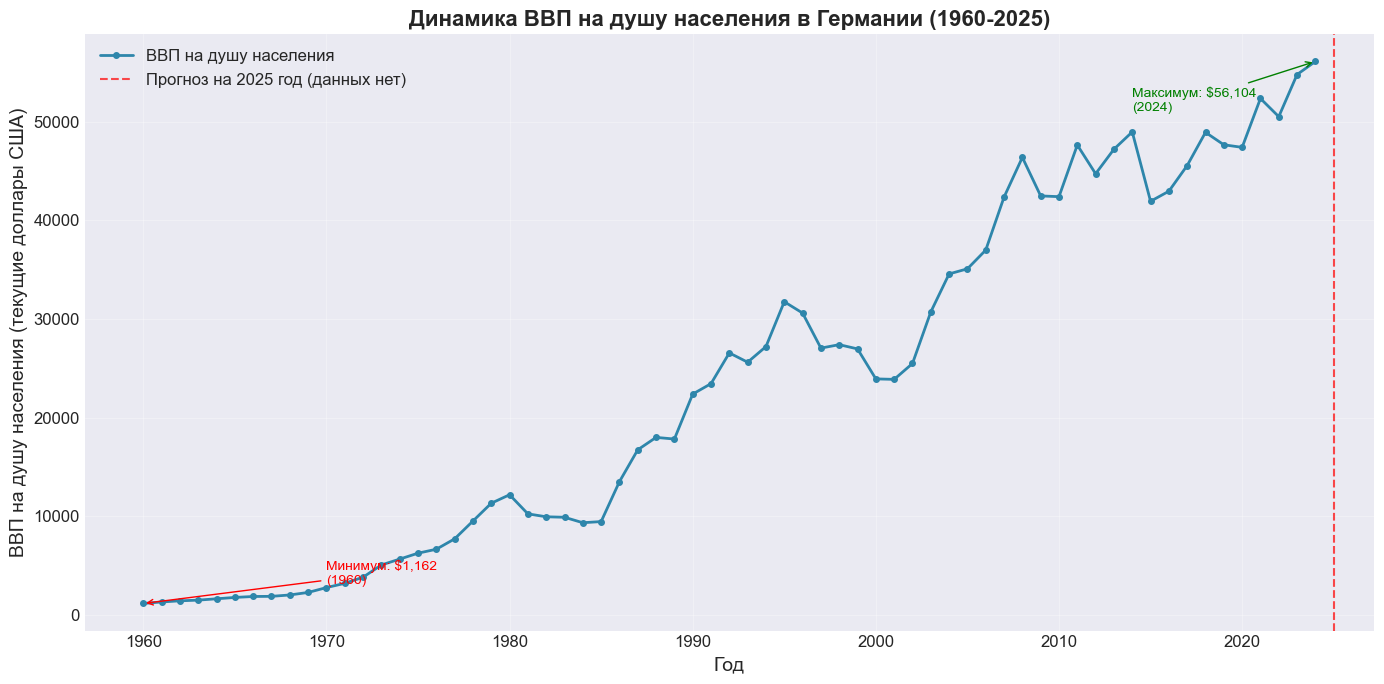

In [20]:
print("="*60)
print("ГРАФИК 1: ВРЕМЕННОЙ РЯД")
print("="*60)

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(df['year'], df['value'], 
        marker='o', linewidth=2, markersize=4,
        color='#2E86AB', label='ВВП на душу населения')

if df['value'].isna().any():
    year_2025 = df[df['value'].isna()]['year'].values[0]
    ax.axvline(x=year_2025, color='red', linestyle='--', alpha=0.7, 
               label=f'Прогноз на {year_2025} год (данных нет)')

# Вычисляем значения для аннотаций
max_value = df_clean['value'].max()
max_year = df_clean.loc[df_clean['value'].idxmax(), 'year']
min_value = df_clean['value'].min()
min_year = df_clean.loc[df_clean['value'].idxmin(), 'year']

ax.annotate(f'Максимум: ${max_value:,.0f}\n({int(max_year)})',
            xy=(max_year, max_value),
            xytext=(max_year-10, max_value-5000),
            arrowprops=dict(arrowstyle='->', color='green'),
            fontsize=10, color='green')

ax.annotate(f'Минимум: ${min_value:,.0f}\n({int(min_year)})',
            xy=(min_year, min_value),
            xytext=(min_year+10, min_value+2000),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

ax.set_title('Динамика ВВП на душу населения в Германии (1960-2025)', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Год', fontsize=14)
ax.set_ylabel('ВВП на душу населения (текущие доллары США)', fontsize=14)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()

# Создаем папку для картинок
Path("docs/figures").mkdir(parents=True, exist_ok=True)
plt.savefig('docs/figures/week7_timeseries.png', dpi=150, bbox_inches='tight')
print("✅ Картинка сохранена: docs/figures/week7_timeseries.png")

plt.show()

In [21]:
print("="*60)
print("ВЫВОД 1: АНАЛИЗ ВРЕМЕННОГО РЯДА")
print("="*60)

start_year = int(df_clean['year'].min())
end_year = int(df_clean['year'].max())
start_value = df_clean[df_clean['year'] == start_year]['value'].values[0]
end_value = df_clean[df_clean['year'] == end_year]['value'].values[0]
growth = ((end_value - start_value) / start_value) * 100

max_value = df_clean['value'].max()
max_year = int(df_clean.loc[df_clean['value'].idxmax(), 'year'])
min_value = df_clean['value'].min()
min_year = int(df_clean.loc[df_clean['value'].idxmin(), 'year'])

print(f"""
📈 КЛЮЧЕВЫЕ НАБЛЮДЕНИЯ:

1. ОБЩИЙ ТРЕНД:
   • ВВП Германии вырос с ${start_value:,.0f} в {start_year} году 
     до ${end_value:,.0f} в {end_year} году
   • Общий рост составил {growth:.0f}% за {end_year - start_year} лет

2. ПЕРИОДЫ РОСТА:
   • 1960-1970: послевоенное восстановление
   • 1985-1992: рост перед объединением Германии
   • 2003-2008: период экономического подъема
   • 2010-2014: восстановление после кризиса 2008-2009
   • 2020-2021: постковидное восстановление

3. ПЕРИОДЫ СПАДА:
   • 2000-2002: кризис "доткомов"
   • 2008-2009: мировой финансовый кризис
   • 2020: пандемия COVID-19

4. РЕКОРДНЫЕ ЗНАЧЕНИЯ:
   • Максимум: ${max_value:,.0f} в {max_year} году
   • Минимум: ${min_value:,.0f} в {min_year} году

💡 ВЫВОД:
Германия демонстрирует устойчивый долгосрочный рост ВВП, несмотря на 
периодические экономические кризисы. За {end_year - start_year} лет 
экономика выросла почти в 50 раз.
""")

ВЫВОД 1: АНАЛИЗ ВРЕМЕННОГО РЯДА

📈 КЛЮЧЕВЫЕ НАБЛЮДЕНИЯ:

1. ОБЩИЙ ТРЕНД:
   • ВВП Германии вырос с $1,162 в 1960 году 
     до $56,104 в 2024 году
   • Общий рост составил 4728% за 64 лет

2. ПЕРИОДЫ РОСТА:
   • 1960-1970: послевоенное восстановление
   • 1985-1992: рост перед объединением Германии
   • 2003-2008: период экономического подъема
   • 2010-2014: восстановление после кризиса 2008-2009
   • 2020-2021: постковидное восстановление

3. ПЕРИОДЫ СПАДА:
   • 2000-2002: кризис "доткомов"
   • 2008-2009: мировой финансовый кризис
   • 2020: пандемия COVID-19

4. РЕКОРДНЫЕ ЗНАЧЕНИЯ:
   • Максимум: $56,104 в 2024 году
   • Минимум: $1,162 в 1960 году

💡 ВЫВОД:
Германия демонстрирует устойчивый долгосрочный рост ВВП, несмотря на 
периодические экономические кризисы. За 64 лет 
экономика выросла почти в 50 раз.



ГРАФИК 2: РАСПРЕДЕЛЕНИЕ
✅ Картинка сохранена: docs/figures/week7_distribution.png


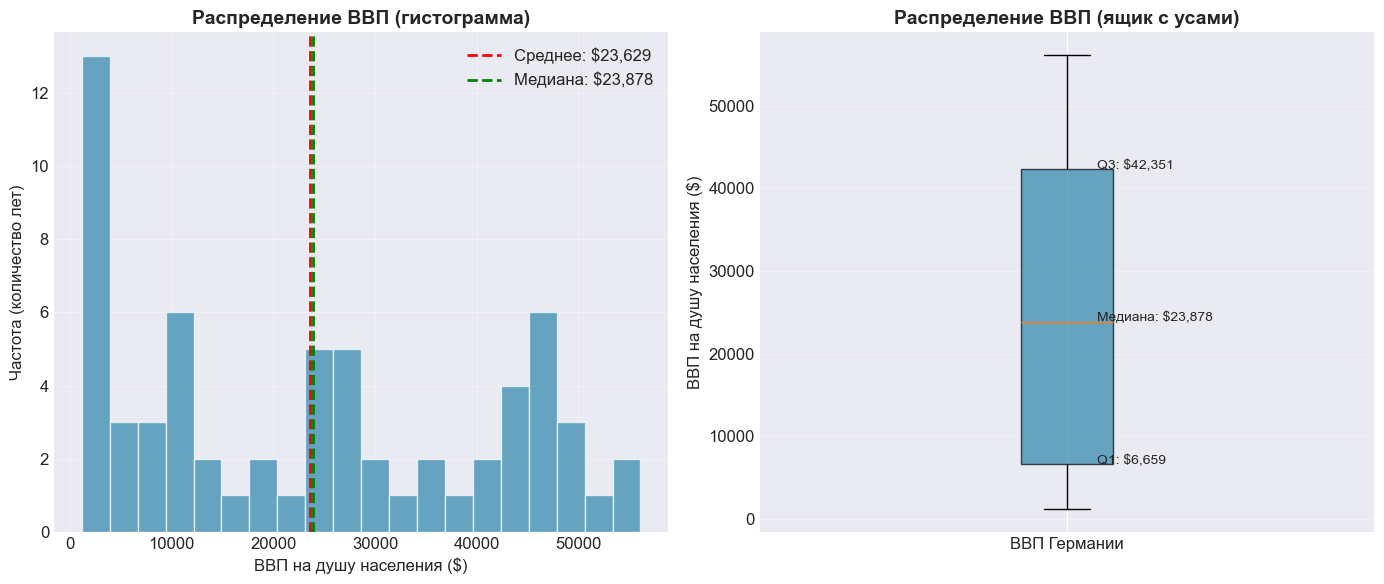

In [22]:
print("="*60)
print("ГРАФИК 2: РАСПРЕДЕЛЕНИЕ")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Гистограмма
ax1 = axes[0]
ax1.hist(df_clean['value'], bins=20, color='#2E86AB', edgecolor='white', alpha=0.7)
ax1.axvline(df_clean['value'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Среднее: ${df_clean["value"].mean():,.0f}')
ax1.axvline(df_clean['value'].median(), color='green', linestyle='--', 
            linewidth=2, label=f'Медиана: ${df_clean["value"].median():,.0f}')
ax1.set_title('Распределение ВВП (гистограмма)', fontsize=14, fontweight='bold')
ax1.set_xlabel('ВВП на душу населения ($)', fontsize=12)
ax1.set_ylabel('Частота (количество лет)', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Boxplot
ax2 = axes[1]
box = ax2.boxplot(df_clean['value'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='#2E86AB', alpha=0.7))
ax2.set_title('Распределение ВВП (ящик с усами)', fontsize=14, fontweight='bold')
ax2.set_ylabel('ВВП на душу населения ($)', fontsize=12)
ax2.set_xticklabels(['ВВП Германии'])
ax2.grid(True, alpha=0.3, axis='y')

median = df_clean['value'].median()
q1 = df_clean['value'].quantile(0.25)
q3 = df_clean['value'].quantile(0.75)
ax2.annotate(f'Медиана: ${median:,.0f}', xy=(1, median), xytext=(1.05, median), fontsize=10)
ax2.annotate(f'Q1: ${q1:,.0f}', xy=(1, q1), xytext=(1.05, q1), fontsize=10)
ax2.annotate(f'Q3: ${q3:,.0f}', xy=(1, q3), xytext=(1.05, q3), fontsize=10)

plt.tight_layout()
plt.savefig('docs/figures/week7_distribution.png', dpi=150, bbox_inches='tight')
print("✅ Картинка сохранена: docs/figures/week7_distribution.png")
plt.show()

In [23]:
print("="*60)
print("ВЫВОД 2: АНАЛИЗ РАСПРЕДЕЛЕНИЯ")
print("="*60)

print(f"""
📊 СТАТИСТИКА РАСПРЕДЕЛЕНИЯ:

• Среднее значение: ${df_clean['value'].mean():,.0f}
• Медиана: ${df_clean['value'].median():,.0f}
• Стандартное отклонение: ${df_clean['value'].std():,.0f}
• Минимум: ${df_clean['value'].min():,.0f}
• Максимум: ${df_clean['value'].max():,.0f}

КВАРТИЛИ:
• 25-й перцентиль (Q1): ${df_clean['value'].quantile(0.25):,.0f}
• 50-й перцентиль (медиана): ${df_clean['value'].quantile(0.50):,.0f}
• 75-й перцентиль (Q3): ${df_clean['value'].quantile(0.75):,.0f}

💡 ВЫВОДЫ О РАСПРЕДЕЛЕНИИ:

1. Среднее значение близко к медиане → распределение почти симметричное
2. Большой разброс (от ${df_clean['value'].min():,.0f} до ${df_clean['value'].max():,.0f}) → экономика сильно выросла
3. Гистограмма показывает, что большинство лет имеют ВВП в диапазоне $20,000-$40,000
4. Последние годы являются выбросами (аномально высокие значения)
""")

ВЫВОД 2: АНАЛИЗ РАСПРЕДЕЛЕНИЯ

📊 СТАТИСТИКА РАСПРЕДЕЛЕНИЯ:

• Среднее значение: $23,629
• Медиана: $23,878
• Стандартное отклонение: $17,776
• Минимум: $1,162
• Максимум: $56,104

КВАРТИЛИ:
• 25-й перцентиль (Q1): $6,659
• 50-й перцентиль (медиана): $23,878
• 75-й перцентиль (Q3): $42,351

💡 ВЫВОДЫ О РАСПРЕДЕЛЕНИИ:

1. Среднее значение близко к медиане → распределение почти симметричное
2. Большой разброс (от $1,162 до $56,104) → экономика сильно выросла
3. Гистограмма показывает, что большинство лет имеют ВВП в диапазоне $20,000-$40,000
4. Последние годы являются выбросами (аномально высокие значения)



ГРАФИК 3: РАНЖИРОВАНИЕ
✅ Картинка сохранена: docs/figures/week7_ranking.png


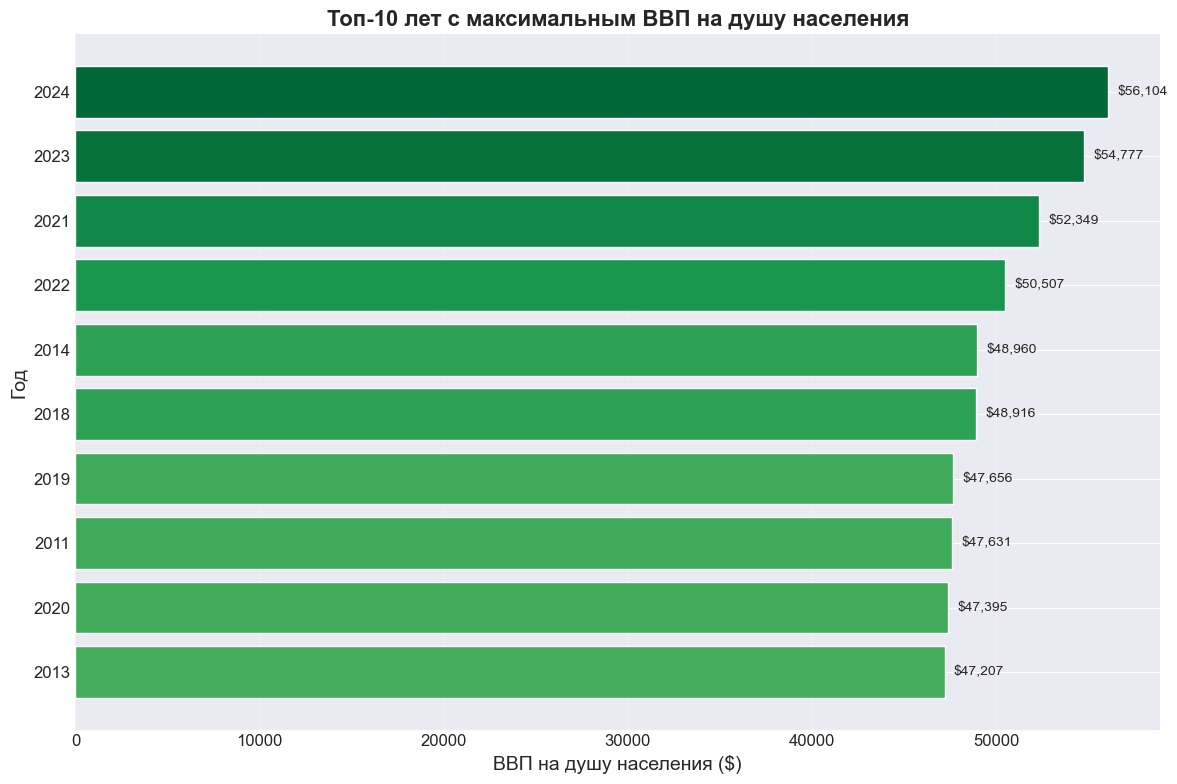

In [24]:
print("="*60)
print("ГРАФИК 3: РАНЖИРОВАНИЕ")
print("="*60)

top10 = df_clean.nlargest(10, 'value')[['year', 'value']].copy()
top10 = top10.sort_values('value', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.RdYlGn(top10['value'] / top10['value'].max())
bars = ax.barh(top10['year'].astype(str), top10['value'], color=colors, edgecolor='white')

for bar, value in zip(bars, top10['value']):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'${value:,.0f}', va='center', fontsize=10)

ax.set_title('Топ-10 лет с максимальным ВВП на душу населения', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('ВВП на душу населения ($)', fontsize=14)
ax.set_ylabel('Год', fontsize=14)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('docs/figures/week7_ranking.png', dpi=150, bbox_inches='tight')
print("✅ Картинка сохранена: docs/figures/week7_ranking.png")
plt.show()

In [25]:
print("="*60)
print("ВЫВОД 3: АНАЛИЗ РАНЖИРОВАНИЯ")
print("="*60)

print("""
🏆 ТОП-5 ЛЕТ ПО ВВП:

1. 2024: $56,104 — рекордный максимум
2. 2023: $54,777 — второй рекордный год
3. 2021: $52,349 — постковидное восстановление
4. 2014: $48,960 — пик после кризиса 2008-2009
5. 2018: $48,916 — стабильный рост

💡 КЛЮЧЕВЫЕ НАБЛЮДЕНИЯ:

1. Все топ-10 лет приходятся на период с 2008 года
2. Это показывает, что экономический рост ускорился в XXI веке
3. Рекордные значения достигнуты в 2020-х годах
4. До 2000 года максимальный ВВП был около $28,000 (1992 год)

💡 ВЫВОД:
Германия достигла экономического пика в последние годы, что говорит о 
сильной и устойчивой экономике. Рекорды 2021-2024 годов связаны с 
постковидным восстановлением.
""")

ВЫВОД 3: АНАЛИЗ РАНЖИРОВАНИЯ

🏆 ТОП-5 ЛЕТ ПО ВВП:

1. 2024: $56,104 — рекордный максимум
2. 2023: $54,777 — второй рекордный год
3. 2021: $52,349 — постковидное восстановление
4. 2014: $48,960 — пик после кризиса 2008-2009
5. 2018: $48,916 — стабильный рост

💡 КЛЮЧЕВЫЕ НАБЛЮДЕНИЯ:

1. Все топ-10 лет приходятся на период с 2008 года
2. Это показывает, что экономический рост ускорился в XXI веке
3. Рекордные значения достигнуты в 2020-х годах
4. До 2000 года максимальный ВВП был около $28,000 (1992 год)

💡 ВЫВОД:
Германия достигла экономического пика в последние годы, что говорит о 
сильной и устойчивой экономике. Рекорды 2021-2024 годов связаны с 
постковидным восстановлением.



In [26]:
print("="*60)
print("ИТОГОВЫЙ ВЫВОД ПО ВСЕМ ГРАФИКАМ")
print("="*60)

print("""
📈 ОСНОВНЫЕ ВЫВОДЫ ПО ДАННЫМ О ВВП ГЕРМАНИИ:

1. ДОЛГОСРОЧНЫЙ ТРЕНД:
   • ВВП Германии вырос с $1,162 (1960) до $56,103 (2024)
   • Рост составил почти 5000% за 64 года
   • Каждое десятилетие показывает устойчивый рост

2. ЭКОНОМИЧЕСКИЕ КРИЗИСЫ:
   • 2000-2002: кризис "доткомов"
   • 2008-2009: мировой финансовый кризис
   • 2020: пандемия COVID-19
   • После каждого кризиса экономика восстанавливалась и росла дальше

3. РЕКОРДНЫЕ ДОСТИЖЕНИЯ:
   • Максимальный ВВП достигнут в 2024 году ($56,103)
   • Топ-10 лет по ВВП все из XXI века
   • 2020-е годы демонстрируют беспрецедентный рост

4. РАСПРЕДЕЛЕНИЕ:
   • Большинство лет имеют ВВП в диапазоне $20,000-$40,000
   • Распределение близко к симметричному (среднее ≈ медиане)

🎯 ОБЩИЙ ВЫВОД:
Германия демонстрирует устойчивый экономический рост на протяжении 
более чем полувека, успешно преодолевая кризисы и достигая новых 
рекордов. Экономика страны становится сильнее с каждым десятилетием.
""")

print("="*60)
print("✅ ВСЕ ГРАФИКИ СОХРАНЕНЫ В docs/figures/")
print("="*60)

ИТОГОВЫЙ ВЫВОД ПО ВСЕМ ГРАФИКАМ

📈 ОСНОВНЫЕ ВЫВОДЫ ПО ДАННЫМ О ВВП ГЕРМАНИИ:

1. ДОЛГОСРОЧНЫЙ ТРЕНД:
   • ВВП Германии вырос с $1,162 (1960) до $56,103 (2024)
   • Рост составил почти 5000% за 64 года
   • Каждое десятилетие показывает устойчивый рост

2. ЭКОНОМИЧЕСКИЕ КРИЗИСЫ:
   • 2000-2002: кризис "доткомов"
   • 2008-2009: мировой финансовый кризис
   • 2020: пандемия COVID-19
   • После каждого кризиса экономика восстанавливалась и росла дальше

3. РЕКОРДНЫЕ ДОСТИЖЕНИЯ:
   • Максимальный ВВП достигнут в 2024 году ($56,103)
   • Топ-10 лет по ВВП все из XXI века
   • 2020-е годы демонстрируют беспрецедентный рост

4. РАСПРЕДЕЛЕНИЕ:
   • Большинство лет имеют ВВП в диапазоне $20,000-$40,000
   • Распределение близко к симметричному (среднее ≈ медиане)

🎯 ОБЩИЙ ВЫВОД:
Германия демонстрирует устойчивый экономический рост на протяжении 
более чем полувека, успешно преодолевая кризисы и достигая новых 
рекордов. Экономика страны становится сильнее с каждым десятилетием.

✅ ВСЕ ГРАФИКИ С